Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.P91NAA_3.0.1/tf_flowers-train.tfrecord*...:   0%|   …

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='tf_flowers',
    full_name='tf_flowers/3.0.1',
    description="""
    A large set of images of flowers
    """,
    homepage='https://www.tensorflow.org/tutorials/load_data/images',
    data_dir='/root/tensorflow_datasets/tf_flowers/3.0.1',
    file_format=tfrecord,
    download_size=218.21 MiB,
    dataset_size=221.83 MiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=5),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=3670, num_shards=2>,
    },
    citation="""@ONLINE {tfflowers,
    author = "The TensorFlow Team",
    title = "Flowers",
    month = "jan",
    year = "2019",
    url = "http://download.ten

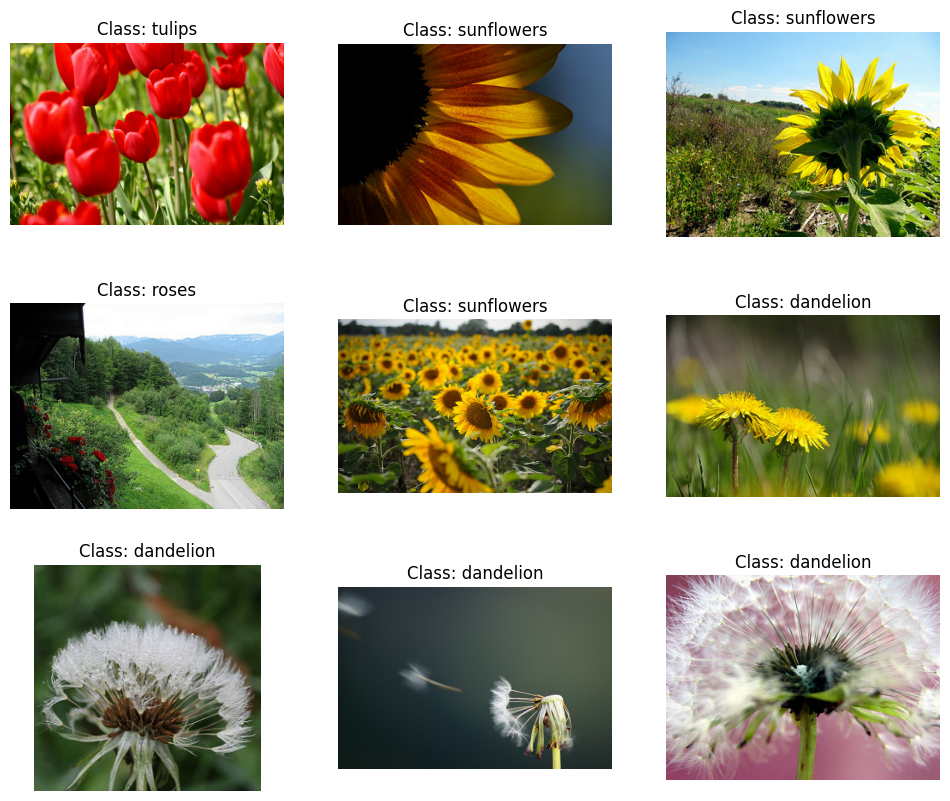

In [1]:
"""
Use a pre-trained Xception model for transfer learning.
Load a dataset (e.g., tf_flowers) and split it into training, validation, and testing datasets.
Pre-process and resize the images.
Create the Keras model and freeze the weights of the pre-trained layers.
Train the model and report the results."
"""

import tensorflow_datasets as tfds
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras




(train_ds, val_ds, test_ds), info = tfds.load(
    "tf_flowers",
    split=["train[:70%]", "train[70%:85%]", "train[85%:]"],
    as_supervised=True,
    with_info=True
)

print(info)

class_names = info.features["label"].names
print(class_names)

n_classes = info.features["label"].num_classes
print(n_classes)

plt.figure(figsize=(12, 10))
index = 0
for image, label in train_ds.take(9):
    index += 1
    plt.subplot(3, 3, index)
    plt.imshow(image)
    plt.title("Class: {}".format(class_names[label]))
    plt.axis("off")

plt.show()


images shape: (224, 224, 3)
labels shape: ()


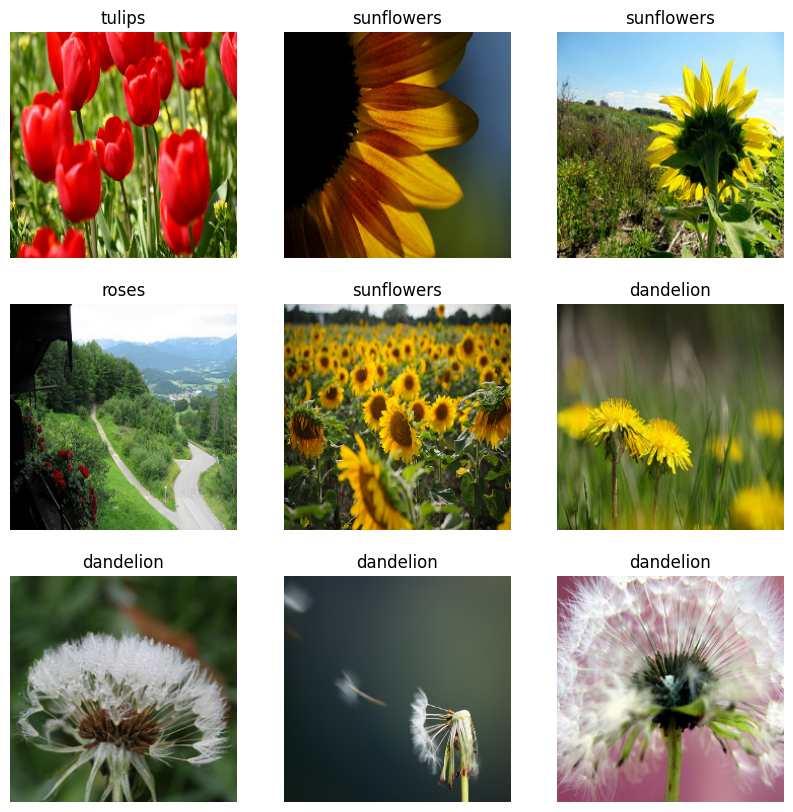

In [2]:
from tensorflow.keras import layers

IMG_SIZE = 224

resize_and_rescale = tf.keras.Sequential([
  layers.Resizing(IMG_SIZE, IMG_SIZE),
  layers.Rescaling(1./255)
])

train_ds = train_ds.map(lambda x, y: (resize_and_rescale(x), y))
val_ds = val_ds.map(lambda x, y: (resize_and_rescale(x), y))
test_ds = test_ds.map(lambda x, y: (resize_and_rescale(x), y))

for images, labels in train_ds.take(1):
    print("images shape:", images.shape)
    print("labels shape:", labels.shape)

plt.figure(figsize=(10,10))
for i, (image, label) in enumerate(train_ds.take(9)):
    plt.subplot(3, 3, i+1)
    plt.imshow(image.numpy())
    plt.title(class_names[int(label.numpy())])
    plt.axis("off")

train_ds = train_ds.batch(32)
val_ds = val_ds.batch(32)
test_ds = test_ds.batch(32)

In [3]:


base_model = keras.applications.xception.Xception(weights="imagenet",
                                                  include_top=False)
avg = keras.layers.GlobalAveragePooling2D()(base_model.output)
output = keras.layers.Dense(n_classes, activation="softmax")(avg)
model = keras.models.Model(inputs=base_model.input, outputs=output)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
for index, layer in enumerate(base_model.layers):
    print(index, layer.name)

0 input_layer_1
1 block1_conv1
2 block1_conv1_bn
3 block1_conv1_act
4 block1_conv2
5 block1_conv2_bn
6 block1_conv2_act
7 block2_sepconv1
8 block2_sepconv1_bn
9 block2_sepconv2_act
10 block2_sepconv2
11 block2_sepconv2_bn
12 conv2d
13 block2_pool
14 batch_normalization
15 add
16 block3_sepconv1_act
17 block3_sepconv1
18 block3_sepconv1_bn
19 block3_sepconv2_act
20 block3_sepconv2
21 block3_sepconv2_bn
22 conv2d_1
23 block3_pool
24 batch_normalization_1
25 add_1
26 block4_sepconv1_act
27 block4_sepconv1
28 block4_sepconv1_bn
29 block4_sepconv2_act
30 block4_sepconv2
31 block4_sepconv2_bn
32 conv2d_2
33 block4_pool
34 batch_normalization_2
35 add_2
36 block5_sepconv1_act
37 block5_sepconv1
38 block5_sepconv1_bn
39 block5_sepconv2_act
40 block5_sepconv2
41 block5_sepconv2_bn
42 block5_sepconv3_act
43 block5_sepconv3
44 block5_sepconv3_bn
45 add_3
46 block6_sepconv1_act
47 block6_sepconv1
48 block6_sepconv1_bn
49 block6_sepconv2_act
50 block6_sepconv2
51 block6_sepconv2_bn
52 block6_sepcon

In [5]:
batch_size = 64
dataset_size = info.splits["train"].num_examples

for layer in base_model.layers:
    layer.trainable = False

optimizer = keras.optimizers.SGD(learning_rate=0.2, momentum=0.9, decay=0.01)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(train_ds, validation_data=val_ds, epochs=5)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


81/81 ━━━━━━━━━━━━━━━━━━━━ 663s 8s/step - accuracy: 0.7073 - loss: 1.6571 - val_accuracy: 0.7713 - val_loss: 2.3052
Epoch 2/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 707s 8s/step - accuracy: 0.8518 - loss: 1.1698 - val_accuracy: 0.8530 - val_loss: 1.0764
Epoch 3/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 683s 8s/step - accuracy: 0.8937 - loss: 0.6966 - val_accuracy: 0.8766 - val_loss: 0.9898
Epoch 4/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 646s 8s/step - accuracy: 0.9105 - loss: 0.6112 - val_accuracy: 0.8984 - val_loss: 0.7746
Epoch 5/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 711s 8s/step - accuracy: 0.9419 - loss: 0.3162 - val_accuracy: 0.8984 - val_loss: 0.8279


In [6]:
keras.backend.clear_session()

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9,
                                 nesterov=True, decay=0.001)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])

early_stopping = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)

hhistory = model.fit(train_ds, validation_data=val_ds, epochs=50, callbacks=[early_stopping])

Epoch 1/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 653s 8s/step - accuracy: 0.9777 - loss: 0.0896 - val_accuracy: 0.9038 - val_loss: 0.7264
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 643s 8s/step - accuracy: 0.9827 - loss: 0.0602 - val_accuracy: 0.8984 - val_loss: 0.7020
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 712s 8s/step - accuracy: 0.9873 - loss: 0.0500 - val_accuracy: 0.9020 - val_loss: 0.6897
Epoch 4/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 650s 8s/step - accuracy: 0.9895 - loss: 0.0434 - val_accuracy: 0.9020 - val_loss: 0.6824
Epoch 5/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 675s 8s/step - accuracy: 0.9903 - loss: 0.0390 - val_accuracy: 0.9002 - val_loss: 0.6780
Epoch 6/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 682s 8s/step - accuracy: 0.9927 - loss: 0.0357 - val_accuracy: 0.9002 - val_loss: 0.6755
Epoch 7/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 714s 8s/step - accuracy: 0.9925 - loss: 0.0330 - val_accuracy: 0.8966 - val_loss: 0.6741
Epoch 8/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 642s 8s/step - accuracy: 0.9929 - loss: 0.0307 - val_accuracy: 0.8966 - v

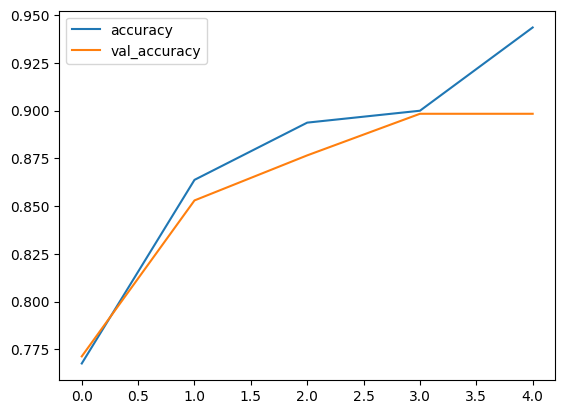

In [7]:
plt.plot(history.history["accuracy"], label="accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.legend()